# Import 

In [1]:
import kagglehub
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

# Export data from kaggle

In [2]:
# Get Notebook Folder
path = Path.cwd()

# Download latest version from kaggle
kagglepath = Path(
    kagglehub.dataset_download('janiobachmann/bank-marketing-dataset')
)

# Destination Folder
destination_folder = path
destination_folder.mkdir(parents=True, exist_ok=True)

# copy file
for file in kagglepath.iterdir() :
    if file.is_file() :
        shutil.copy2(file, destination_folder / file.name)

print(f'data saved in : \n {path}')

data saved in : 
 e:\Hacktiv8\Project\Banking Marketing Dataset


# Business Background

Dalam industri perbankan, dana pihak ketiga seperti tabungan, giro, dan deposito merupakan sumber pendanaan utama yang digunakan untuk mendukung aktivitas operasional dan penyaluran kredit. Oleh karena itu, meningkatkan jumlah nasabah yang bersedia membuka deposito menjadi salah satu target penting bagi divisi pemasaran bank.

Setiap aktivitas pemasaran membutuhkan biaya, termasuk biaya komunikasi, tenaga pemasaran, waktu operasional, serta pengelolaan hubungan dengan pelanggan. Karena tidak semua nasabah memiliki minat terhadap produk deposito, menghubungi seluruh nasabah tanpa strategi yang tepat dapat menyebabkan penggunaan sumber daya yang kurang efisien.

Melalui data historis hasil kampanye pemasaran, bank memiliki kesempatan untuk mengevaluasi faktor-faktor yang berkaitan dengan keberhasilan maupun kegagalan suatu campaign. Analisis tersebut dapat membantu memahami karakteristik pelanggan, efektivitas strategi pemasaran, serta pola respons pelanggan terhadap penawaran yang diberikan.


# Business Context

Bank secara rutin menjalankan kampanye pemasaran melalui telepon untuk menawarkan produk term deposit kepada pelanggan yang sudah ada maupun calon pelanggan. Setiap panggilan yang dilakukan memerlukan sumber daya berupa tenaga pemasaran, waktu, serta biaya operasional.

Meskipun campaign telah dilakukan kepada ribuan pelanggan, hanya sebagian kecil yang akhirnya memutuskan untuk membuka deposito. Kondisi ini menunjukkan bahwa tidak semua pelanggan memiliki peluang yang sama untuk menerima penawaran tersebut.

Oleh karena itu, pihak manajemen membutuhkan pemahaman mengenai faktor-faktor yang berkaitan dengan keberhasilan subscription. Informasi tersebut diharapkan dapat membantu tim pemasaran dalam menentukan segmen pelanggan yang lebih potensial, mengevaluasi efektivitas campaign, serta mengalokasikan sumber daya pemasaran secara lebih efisien.

# Problem Identification

Bank secara rutin menjalankan kampanye pemasaran melalui telepon untuk menawarkan produk deposito berjangka (term deposit) kepada nasabah. Namun, setiap aktivitas pemasaran memerlukan biaya operasional, tenaga kerja, dan waktu yang tidak sedikit. Di sisi lain, tidak semua nasabah yang dihubungi bersedia membuka deposito.

Tanpa mengetahui karakteristik nasabah yang lebih berpotensi menerima penawaran serta faktor-faktor yang memengaruhi keberhasilan kampanye, bank berisiko mengalokasikan sumber daya pemasaran secara kurang efektif. Oleh karena itu, diperlukan analisis terhadap data historis untuk memahami pola keberhasilan campaign sehingga strategi pemasaran berikutnya dapat disusun dengan lebih tepat sasaran.

## SMART Method

### Specific

Mengidentifikasi karakteristik nasabah serta faktor-faktor campaign yang berkaitan dengan keputusan nasabah untuk berlangganan deposito

### Measurable

Mengidentifikasi faktor-faktor yang memiliki hubungan signifikan terhadap keberhasilan campaign, mengukur conversion rate pada setiap segmen nasabah

### Achievable

Menyusun rekomendasi strategi campaign berdasarkan hasil analisis data historis untuk membantu meningkatkan efektivitas campaign

### Relevant

- Bank dapat memahami karakteristik nasabah potensial berlangganan deposito

- bank dapat mengevaluasi strategi campaign

- Bank dapat mengambil keputusan yang lebih efektif melalui data dan meningkatkan efisiensi sumber daya

### Time - Bound

Analisis dilakukan menggunakan data historis sebagai dasar penyusunan rekomendasi strategi campaign yang dapat diterapkan pada periode campaign berikutnya

# Scope Project

Analisis pada project ini difokuskan pada evaluasi efektivitas campaign pemasaran deposito berdasarkan data historis yang tersedia. Pembahasan mencakup analisis karakteristik nasabah, kondisi finansial, serta faktor-faktor campaign yang berkaitan dengan keputusan nasabah untuk berlangganan produk deposito

# Data

## Data Source

Data source yang digunakan adalah data 'Bank Marketing Dataset' yang berasal dari kaggle, tentang data historis hasil campaign deposito yang dilakukan oleh sebuah bank. Campaign dilakukan melalui telepon. Setiap baris pada dataset merupakan representasi dari satu aktivitas campaign terhadap nasabah.

## Import & Understanding Data

In [3]:
df = pd.read_csv('bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [5]:
print(f'jumlah baris : {df.shape[0]}')
print(f'jumlah kolom : {df.shape[1]}')

jumlah baris : 11162
jumlah kolom : 17


In [6]:
print('Struktur dataset : \n')
df.info()
print('\n\n Statistik Deskriptif :')
df.describe().T

Struktur dataset : 

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


 Statistik Deskriptif :


,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

## Data Summary

Berdasarkan understanding data yang dilakukan pada dataset, terdapat 17 variabel atau kolom dan 11.162 baris data. Tidak terdapat missing value ataupun duplikat value.

# Business Question / Analytical Question

1. Bagaimana distribusi dari campaign deposito yang dilakukan oleh bank secara menyeluruh?
2. Bagaimana karakteristik nasabah yang memiliki kecendrungan tinggi dalam berlangganan deposito?
3. Apakah ada hubungan pada financial nasabah terhadap minat mereka untuk berlangganan deposito?
4. Bagaimana performa campaign pemasaran dalam meningkatkan subscription deposito?

# EDA & Business Insight

## Question 1

Bagaimana distribusi dari campaign deposito yang dilakukan oleh bank secara menyeluruh?

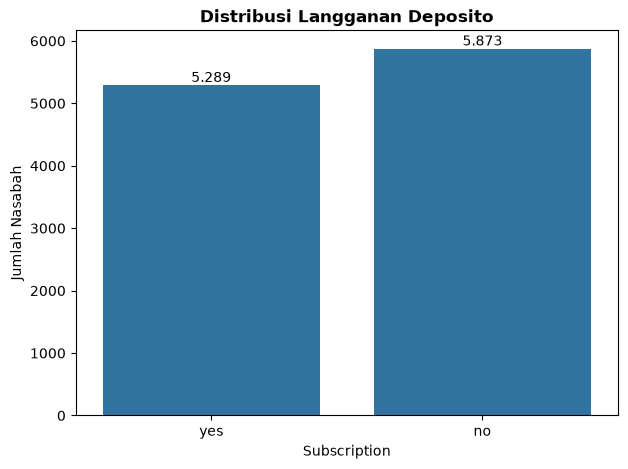

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, 
                   x='deposit', 
                   legend=False)

ax.set(
    title='Distribusi Langganan Deposito', 
    xlabel='Subscription', 
    ylabel='Jumlah Nasabah')

ax.title.set_weight('bold')

for container in ax.containers :
    value_label = [f'{value:,.0f}'.replace(',', '.') for value in container.datavalues] # Melaukan formatting pada value label
    ax.bar_label(container, labels=value_label) # Menampilkan Value Label apda setiap Bar

plt.show()

Insight :

Berdasarkan grafik, dari 11.162 Nasabah yang dihubungi, hanya sebanyak 5.289 nasabah yang memutuskan untuk berlangganan deposito, sementara 5.873 tidak. Hal ini menunjukkan jika tingkat keberhasil dari campaign yang dilakukan masih relatif rendah sehingga sebagian besar nasabah belum berhasil dikonversi untuk berlangganan deposito.

## Question 2

Bagaimana karakteristik nasabah yang memiliki kecendrungan tinggi dalam berlangganan deposito?

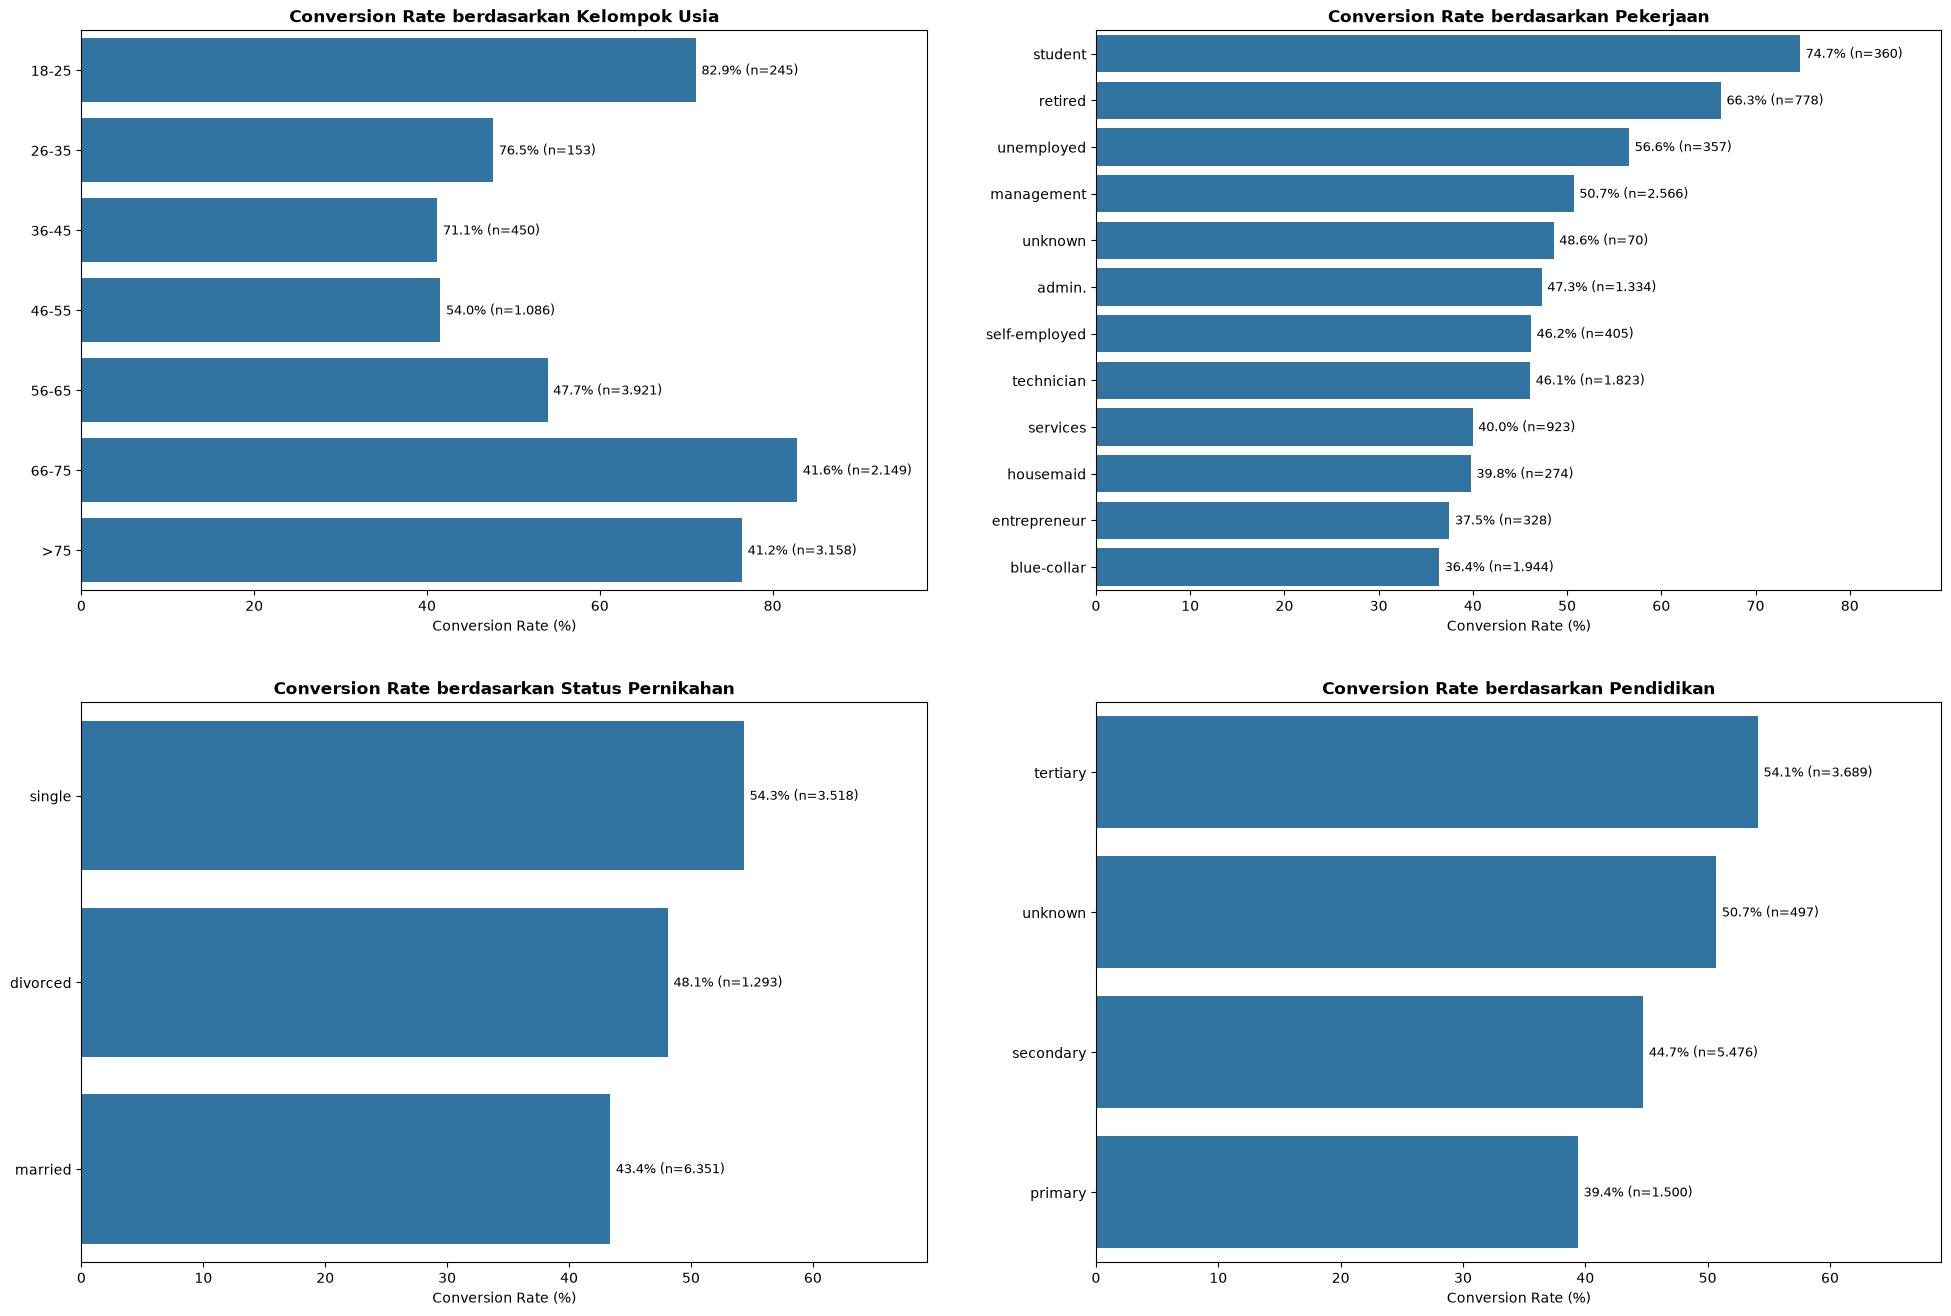

In [11]:
# Kategori usia
ages = [18, 25, 35, 45, 55, 65, 75, 100]
age_labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '66-75',
    '>75'
]

df_plot = df.copy()

df_plot['age_category'] = pd.cut(
    df_plot['age'],
    bins=ages,
    labels=age_labels,
    include_lowest=True
)

# Hitung Conversion Rate
def conversion_rate(data, column):

    result = (
        data.groupby(column, observed=True)
        .agg(
            total_nasabah=('deposit', 'count'),
            conversion_rate=('deposit', lambda x: (x == 'yes').mean() * 100)
        )
        .reset_index()
        .sort_values('conversion_rate', ascending=False)
    )

    return result


# Visualisasi
fig, axes = plt.subplots(
    2, 2,
    figsize=(24, 16)
)

columns = [
    'age_category',
    'job',
    'marital',
    'education'
]

titles = [
    'Kelompok Usia',
    'Pekerjaan',
    'Status Pernikahan',
    'Pendidikan'
]

for ax, column, title in zip(
    axes.flatten(),
    columns,
    titles
):

    plot_data = conversion_rate(df_plot, column)

    sns.barplot(
        data=plot_data,
        x='conversion_rate',
        y=column,
        legend=False,
        ax=ax
    )

    ax.set(
        title=f'Conversion Rate berdasarkan {title}',
        xlabel='Conversion Rate (%)',
        ylabel=''
    )

    ax.title.set_weight('bold')

    ax.set_xlim(0, plot_data['conversion_rate'].max() + 15)

    labels = [
        f'{rate:.1f}% (n={total:,})'.replace(',', '.')
        for rate, total in zip(
            plot_data['conversion_rate'],
            plot_data['total_nasabah']
        )
    ]

    ax.bar_label(
        ax.containers[0],
        labels=labels,
        padding=4,
        fontsize=9
    )

plt.show()

Insight :

Dengan grafik di atas dapat kita lihat karakteristik nasabah yang paling banyak dilakukan konversi berlangganan deposito.
- Berdasarkan kategori umur, kebanyakan dari kalangan orang berumur sektiar 18-25 tahun dengan 82,9% terkonversi
- Berdasarkan kategori pekerjaan, secara konversi rate, student adalah yang terbanyak dengan 74,7%
- Berdasarkan status pernikahan, orang yang masih single justru lebih banyak terkonversi dengan 54,3%
- Berdasarkan kategori pendidikan, tertiary terkonversi terbanyak dengan 54,1%

## Question 3

Apakah ada hubungan pada financial nasabah terhadap minat mereka untuk berlangganan deposito?

In [12]:
# lihat statistik balance
df['balance'].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

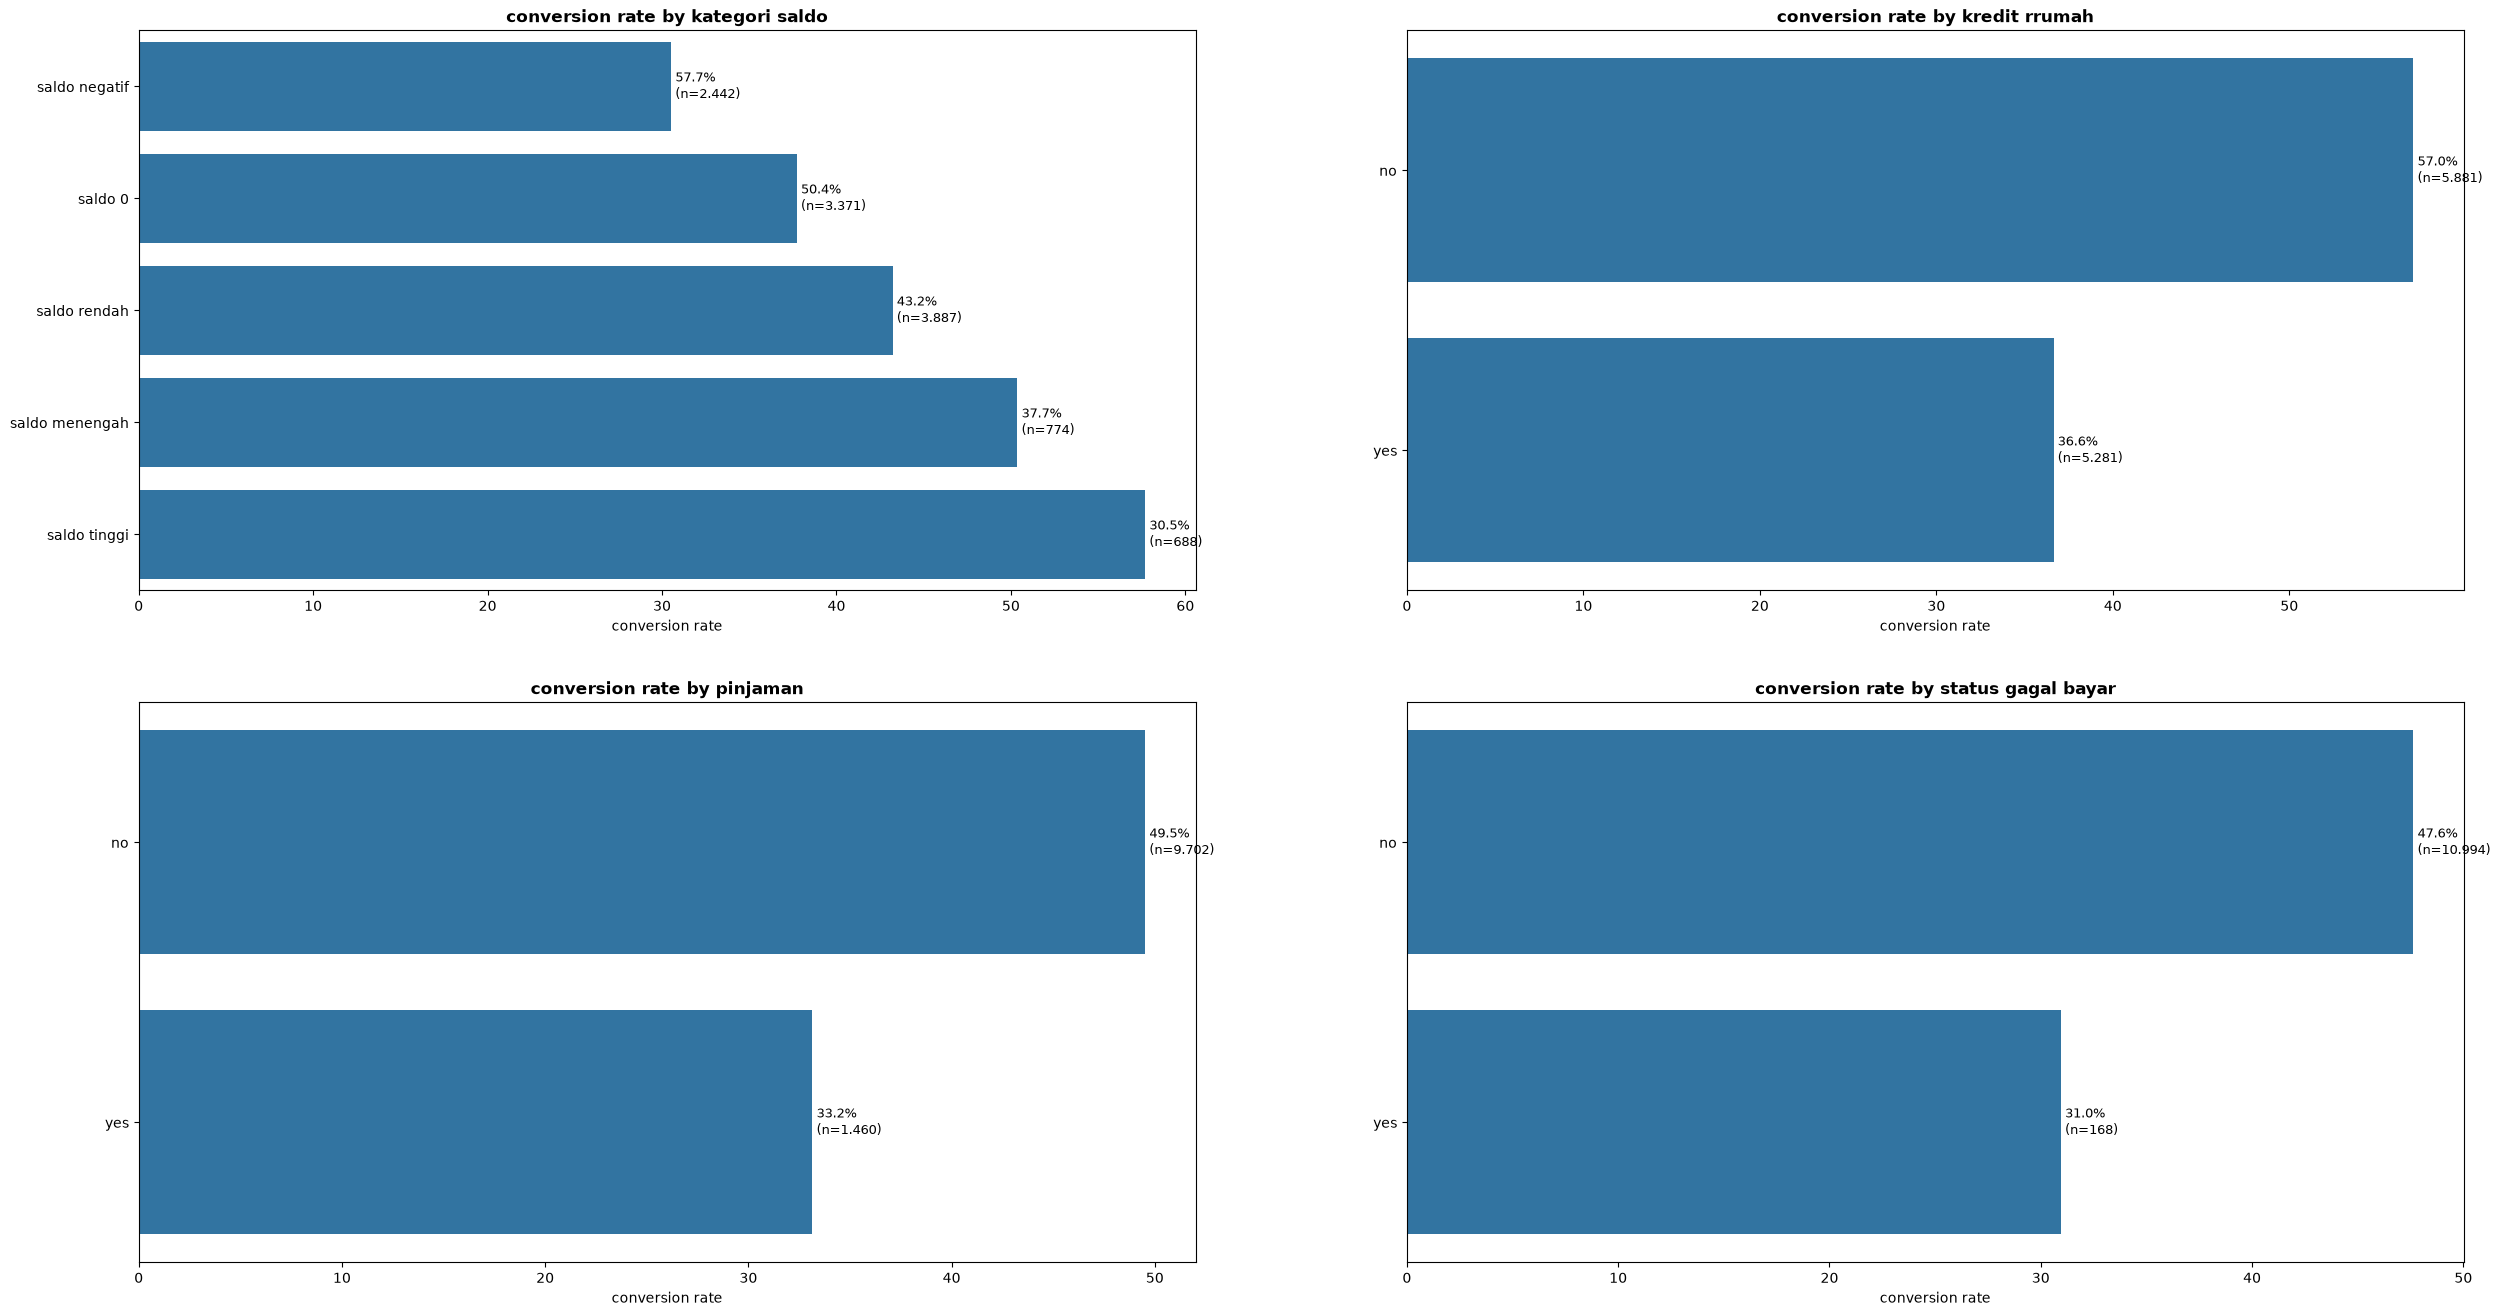

In [13]:
df_plot = df.copy()

bals = [
    df_plot['balance'] < 0,
    df_plot['balance'] == 0,
    (df_plot['balance'] >= 1) & (df_plot['balance'] <= 500),
    (df_plot['balance'] >= 501) & (df_plot['balance'] <= 2000),
    df_plot['balance'] > 2000
]

bal_category = [
    'saldo negatif',
    'saldo 0',
    'saldo rendah',
    'saldo menengah',
    'saldo tinggi'
]

df_plot['balance_category'] = np.select(
    bals,
    bal_category,
    default = 'Unknown'
)

df_plot['balance_category'] = pd.Categorical(
    df_plot['balance_category'],
    categories = bal_category,
    ordered = True
)

# Visualisasi
fig, axes = plt.subplots(
    2,2,
    figsize = (30,16)
)

columns = [
    'balance_category',
    'housing',
    'loan',
    'default'
]

titles = [
    'kategori saldo',
    'kredit rrumah',
    'pinjaman',
    'status gagal bayar'
]

for ax, column, title in zip(
    axes.flatten(),
    columns,
    titles
) :
    plot_data = conversion_rate(df_plot, column)

    sns.barplot(
        data = plot_data,
        x = 'conversion_rate',
        y = column,
        ax = ax,
        legend = False
    )

    ax.set(
        title = f'conversion rate by {title}',
        xlabel = 'conversion rate',
        ylabel = ''
    )

    ax.title.set_weight('bold')

    labels = [
        f"{rate:.1f}%\n(n={total:,})".replace(",", ".")
        for rate, total in zip(
            plot_data["conversion_rate"],
            plot_data["total_nasabah"]
        )
    ]

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

plt.show()

Insight :
- Berdasarkan kategori saldo, nasabah dengan saldo tinggi adalah target konversi terbanyak dengan 57,7%
- Berdasarkan kategori kredit rumah, nasabah yang tidak memiliki kredit rumah memiliki jumlah konversi lebih banayk yaitu 57%
- Berdasarkan kategori pinjaman, nasabah tanpa pinjaman terkonversi lebih banyak dengan 49,5%
- Berdasarkan kategori kredit gagal bayar, nasabah yang tidak memiliki riwayat gagal bayar berhasil dikonversi lebih banyak yaitu 47,6%


## Question 4

Bagaimana performa campaign pemasaran dalam meningkatkan subscription deposito?

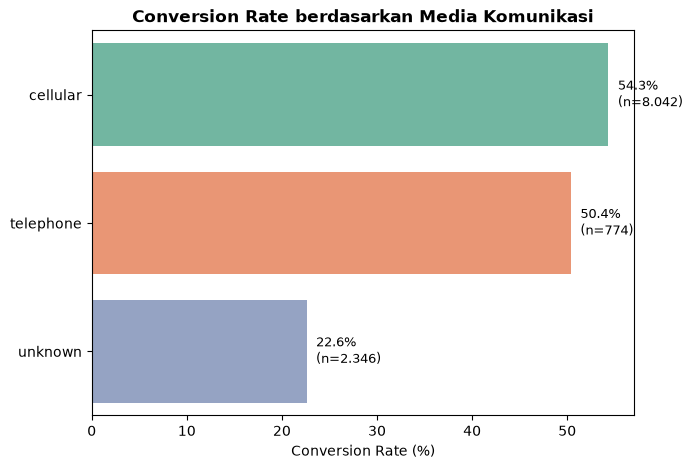

In [14]:
contact_plot = (
    df.groupby("contact", observed=True)
    .agg(
        total_nasabah=("deposit", "count"),
        conversion_rate=("deposit", lambda x: (x == "yes").mean() * 100)
    )
    .reset_index()
    .sort_values("conversion_rate", ascending=False)
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=contact_plot,
    x="conversion_rate",
    y="contact",
    palette="Set2",
    hue="contact",
    legend=False
)

ax.set(
    title="Conversion Rate berdasarkan Media Komunikasi",
    xlabel="Conversion Rate (%)",
    ylabel=""
)

ax.title.set_weight("bold")

# Value Label
for i, row in contact_plot.iterrows():

    ax.text(
        row["conversion_rate"] + 1,
        i,
        f'{row["conversion_rate"]:.1f}%\n(n={row["total_nasabah"]:,})'.replace(",", "."),
        va="center",
        fontsize=9
    )

plt.show()

Insight :

Visualisasi menunjukkan bahwa media komunikasi cellular memiliki conversion rate sebesar 54,3%, sedikit lebih tinggi dibandingkan telephone yang memiliki conversion rate 50,4%.

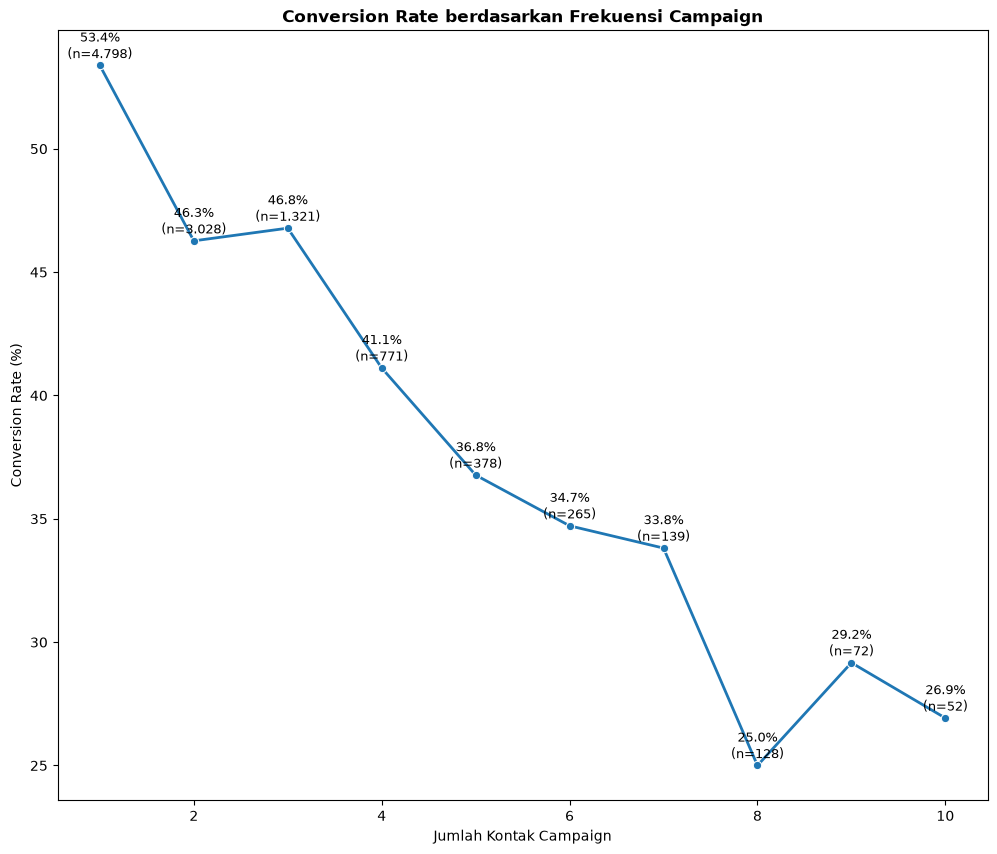

In [15]:
campaign_plot = (
    df.groupby("campaign", observed=True)
    .agg(
        total_nasabah=("deposit", "count"),
        conversion_rate=("deposit", lambda x: (x == "yes").mean() * 100)
    )
    .reset_index()
)

campaign_plot = campaign_plot[
    campaign_plot["campaign"] <= 10
]

plt.figure(figsize=(12,10))

ax = sns.lineplot(
    data=campaign_plot,
    x="campaign",
    y="conversion_rate",
    marker="o",
    linewidth=2
)

ax.set(
    title="Conversion Rate berdasarkan Frekuensi Campaign",
    xlabel="Jumlah Kontak Campaign",
    ylabel="Conversion Rate (%)"
)

ax.title.set_weight("bold")

for _, row in campaign_plot.iterrows():

    ax.text(
        row["campaign"],
        row["conversion_rate"] + 0.3,
        f"{row['conversion_rate']:.1f}%\n(n={int(row['total_nasabah']):,})".replace(",", "."),
        ha="center",
        fontsize=9
    )

plt.show()

Insight :

Conversion rate tertinggi terjadi pada kontak pertama nasabah sebesar 53,4%. setelah terjadinya kontak hingga 4 kali, conversion rate cenderung menurun. Hal ini menunjukkan bahwasannya keberhasilan campaign lebih banyak terjadi ketika dilakukannya kontak 1-3 kali, sementara melakukan follow-up secara berulang cenderung berkaitan dengan tingkat keberhasilan campaign yang lebih rendah.

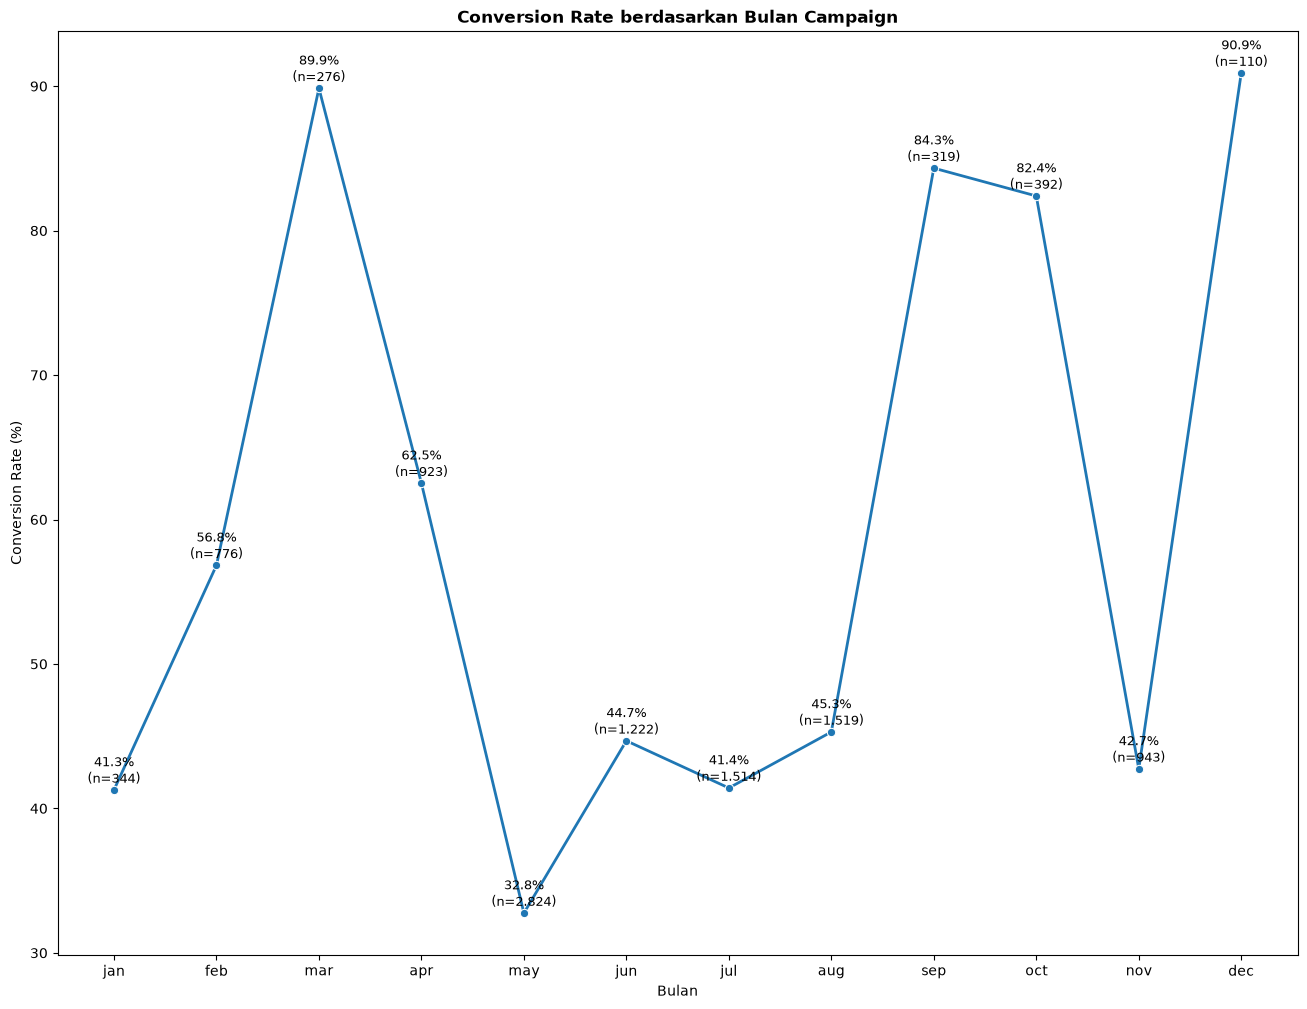

In [16]:
month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]

df_plot = df.copy()

df_plot['month'] = pd.Categorical(
    df_plot['month'],
    categories=month_order,
    ordered=True
)

month_plot = (
    df_plot.groupby('month', observed=True)
    .agg(
        total_nasabah=('deposit', 'count'),
        conversion_rate=('deposit',
                         lambda x: (x == 'yes').mean() * 100)
    )
    .reset_index()
)

plt.figure(figsize=(16,12))

ax = sns.lineplot(
    data=month_plot,
    x='month',
    y='conversion_rate',
    marker='o',
    linewidth=2
)

ax.set(
    title='Conversion Rate berdasarkan Bulan Campaign',
    xlabel='Bulan',
    ylabel='Conversion Rate (%)'
)

ax.title.set_weight('bold')

for _, row in month_plot.iterrows():

    ax.text(
        row['month'],
        row['conversion_rate'] + 0.5,
        f"{row['conversion_rate']:.1f}%\n(n={row['total_nasabah']:,})".replace(",", "."),
        ha='center',
        fontsize=9
    )

plt.show()

Insight :

Conversion rate tertinggi terjadi pada bulen Desember sebesar 90,9%. Namun angka campaign pada bulan tersebut relatif lebih rendah dibanding bulan-bulan lainnya. Misal pada bulan Mei, jumlah campaign terbanyak dengan 2.824 nasabah yang hanya terkonversi berlangganan deposito sebesar 32,8%

# Statistical Analytics

In [17]:
alpha = 0.05

## Variabel Age, Balance, Campaign

In [18]:
def mann_whitney_test(data, column, target='deposit', alpha=0.05):
    
    group_yes = data[data[target] == 'yes'][column]
    group_no = data[data[target] == 'no'][column]

    statistic, p_value = mannwhitneyu(
        group_yes,
        group_no,
        alternative='two-sided'
    )

    print("="*60)
    print(f"Mann-Whitney U Test : {column.upper()}")
    print("="*60)

    print(f"U-Statistic : {statistic:,.2f}")

    if p_value < 0.001:
        print("P-Value     : < 0.001")
    else:
        print(f"P-Value     : {p_value:.3f}")

    print()

    if p_value < alpha:
        print("Decision : Reject H0")
        print(f"Conclusion : Terdapat perbedaan yang signifikan pada '{column}' antara nasabah yang berlangganan dan tidak berlangganan deposito.")
    else:
        print("Decision : Fail to Reject H0")
        print(f"Conclusion : Tidak terdapat perbedaan yang signifikan pada '{column}' antara nasabah yang berlangganan dan tidak berlangganan deposito.")

    print("\n")

In [19]:
mann_whitney_test(df, "age")
mann_whitney_test(df, "balance")
mann_whitney_test(df, "campaign")

Mann-Whitney U Test : AGE
U-Statistic : 15,312,933.00
P-Value     : 0.199

Decision : Fail to Reject H0
Conclusion : Tidak terdapat perbedaan yang signifikan pada 'age' antara nasabah yang berlangganan dan tidak berlangganan deposito.


Mann-Whitney U Test : BALANCE
U-Statistic : 18,360,634.00
P-Value     : < 0.001

Decision : Reject H0
Conclusion : Terdapat perbedaan yang signifikan pada 'balance' antara nasabah yang berlangganan dan tidak berlangganan deposito.


Mann-Whitney U Test : CAMPAIGN
U-Statistic : 13,374,873.50
P-Value     : < 0.001

Decision : Reject H0
Conclusion : Terdapat perbedaan yang signifikan pada 'campaign' antara nasabah yang berlangganan dan tidak berlangganan deposito.




# Variabel Kategorikal

In [20]:
def chi_square_test(data, column, target='deposit', alpha=0.05):

    contingency_table = pd.crosstab(
        data[column],
        data[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    print("="*60)
    print(f"Chi-Square Test : {column.upper()}")
    print("="*60)

    print(f"Chi-Square Statistic : {chi2:.2f}")
    print(f"Degree of Freedom    : {dof}")

    if p_value < 0.001:
        print("P-Value              : < 0.001")
    else:
        print(f"P-Value              : {p_value:.3f}")

    print()

    if p_value < alpha:
        print("Decision : Reject H0")
        print(f"Conclusion : Terdapat hubungan yang signifikan antara '{column}' dan subscription deposito.")
    else:
        print("Decision : Fail to Reject H0")
        print(f"Conclusion : Tidak terdapat hubungan yang signifikan antara '{column}' dan subscription deposito.")

    print("\n")

In [21]:
chi_square_test(df, "job")
chi_square_test(df, "marital")
chi_square_test(df, "education")

Chi-Square Test : JOB
Chi-Square Statistic : 378.08
Degree of Freedom    : 11
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'job' dan subscription deposito.


Chi-Square Test : MARITAL
Chi-Square Statistic : 109.58
Degree of Freedom    : 2
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'marital' dan subscription deposito.


Chi-Square Test : EDUCATION
Chi-Square Statistic : 122.77
Degree of Freedom    : 3
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'education' dan subscription deposito.




In [22]:
chi_square_test(df, "housing")
chi_square_test(df, "loan")
chi_square_test(df, "default")

Chi-Square Test : HOUSING
Chi-Square Statistic : 463.19
Degree of Freedom    : 1
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'housing' dan subscription deposito.




Chi-Square Test : LOAN
Chi-Square Statistic : 135.83
Degree of Freedom    : 1
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'loan' dan subscription deposito.


Chi-Square Test : DEFAULT
Chi-Square Statistic : 17.81
Degree of Freedom    : 1
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'default' dan subscription deposito.




In [23]:
chi_square_test(df, "contact")

Chi-Square Test : CONTACT
Chi-Square Statistic : 736.69
Degree of Freedom    : 2
P-Value              : < 0.001

Decision : Reject H0
Conclusion : Terdapat hubungan yang signifikan antara 'contact' dan subscription deposito.




# Business Conclusion / Kesimpulan

Berdasarkan dari hasil analisis yang telah dilakukan, makan dapat disimpulkan :

1. Nasabah dengan usia muda, status single, dan memiliki pendidikan yang tinggi menunjukkan tingkat conversion rate berlangganan deposito yang relatif lebih tinggi dibandignkan kelompok lainnya.

2. Nasabah dengan saldo yang tinggi memiliki tingkat conversion rate yang tinggi. Selain itu nasabah yang tidak memiliki pinjaman, kredit rumah, dan riwayat gagal bayar juga menunjukkan conversion rate yang tinggi.

3. Convertion rate tertinggi terjadi pada kontak pertama kepada nasabah yaitu 53,4%. Kemudian cenderung menurun semakin bertambahnya jumlah follow-up yang dilakukan. Hal ini menunjukkan jika campaign sebaiknya dilakukan 1-3 kali kontak saja.

4. Bulan-bulan terbaik melakukan campaign ada pada Maret, September, Oktober, dan Desember karena memiliki conversion rate yang relatif tinggi dibanding bulan-bulan lainnya. Walaupun sebenarnya jumlah campaign pada bulan-bulan tersebut relatif lebih rendah dibanding bulan-bulan lainnya sehingga perlu interpretasi dengan ukuran sampel campaign yang dilakukan.

# Action Plan

1. Prioritas campaign difokuskan kepada nasabah-nasabah dengan kriteria :
    - Kelompok usia muda
    - Memiliki pendidikan tinggi
    - Berstatus single
    - Memiliki saldo tinggi
    - Tidak memiliki kredit rumat, pinjaman, dan riwayat gagal bayar.

2. Prioritaskan keberhasilan campaign pada kontak 1-3 kali saja. Jika nasabah belum tertarik berlangganan deposito setelah 3 kali kontak, maka pertimbangkan untuk mengalihkan sumber daya ke nasabah lainnya yang memiliki potensi tinggi untuk berlangganan.

3. Penggunaan media cellular diutamakan karena conversionnya tinggi. 

4. Waktu campaign terbaik dapat menyesuaikan hasil analisis. 